# Exploratory Data Analysis

**Paper:** *Deep learning-based surrogate capacity models and multi-objective fragility estimates for reinforced concrete frames*
**Authors:** Lili Xing, Paolo Gardoni, Ge Song, Ying Zhou

This notebook visualizes the cleaned DNN dataset stored at `1. Dataset/DNN_dataset_cleaned.csv`.

## 1. Imports and Dataset Path

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 120})
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


def find_project_root(start: Path = Path.cwd()) -> Path:
    for path in (start, *start.parents):
        if (path / "1. Dataset" / "DNN_dataset_cleaned.csv").exists():
            return path
    raise FileNotFoundError("Could not find 1. Dataset/DNN_dataset_cleaned.csv from the current directory.")


BASE_DIR = find_project_root()
CSV_PATH = BASE_DIR / "1. Dataset" / "DNN_dataset_cleaned.csv"
print(CSV_PATH)

c:\Users\ASUS\Desktop\Prof.-Gardoni-Paper-Reproduction-Work\1. Dataset\DNN_dataset_cleaned.csv


## 2. Load the Cleaned CSV

In [37]:
df = pd.read_csv(CSV_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 110,649
Columns: 42


,B,D,H,B_num,D_num,H_num,colWidth,beamDepth,beamRat,Asc,Asb,t,cover1,cover2,Ec,nu_c,fc,fcuRat,eps_cu,Es,nu_s,fsy,eta,Dy,Vy,Du,Vu,IDy,IVy,IDu,IVu,eps_c0,lambda_,fct,Ecs,R0,cR1,cR2,a1,a2,a3,a4
0,3.872590,6.336304,4.928144,3.027105,3.212143,2.501537,0.591043,0.651065,0.378389,760.4216,446.4911,0.221685,0.024809,0.02435,3.194428,0.183732,16.48022,0.238605,0.003176,2.117064,0.343586,369.3169,0.016468,0.378479,2561.220,1.273374,2833.483,0.4928,2603.773,2.3984,2833.483,0.001032,0.1,1.648022,824.0110,20.0,0.9215,0.15,0.0,1.0,0.0,0.0
1,7.009406,3.241430,3.967510,2.281663,4.451455,5.059249,0.458534,0.740647,0.467227,281.3511,138.2111,0.209036,0.045935,0.04653,3.212880,0.216622,25.06127,0.202102,0.003331,2.052890,0.264926,444.6774,0.038714,0.203165,1467.264,0.538122,2325.176,0.2923,1448.344,0.8131,2325.176,0.001560,0.1,2.506127,1253.0635,20.0,0.9215,0.15,0.0,1.0,0.0,0.0
2,8.587800,3.878700,4.854900,2.851900,4.516200,2.620700,1.028400,1.108600,0.460200,281.8100,441.4800,0.226400,0.024200,0.02180,3.007600,0.180900,28.49500,0.232000,0.001200,2.017400,0.318300,354.5900,0.036700,0.137770,5877.000,0.275300,8737.400,0.2200,6665.200,0.3700,8737.400,0.001895,0.1,2.849500,1424.7500,20.0,0.9215,0.15,0.0,1.0,0.0,0.0
3,8.431800,6.559000,4.038600,2.268600,4.982600,1.623800,0.748700,1.092500,0.462200,368.0500,416.1600,0.150800,0.030500,0.03110,3.299100,0.186400,25.65600,0.232700,0.001300,2.008900,0.282900,401.1100,0.009300,0.134040,4767.100,0.244200,5891.100,0.2200,4767.100,0.4000,5891.100,0.001555,0.1,2.565600,1282.8000,20.0,0.9215,0.15,0.0,1.0,0.0,0.0
4,4.032500,6.753100,3.339800,4.185100,3.183900,3.058300,1.106600,0.722300,0.372200,569.8600,384.7200,0.170900,0.032200,0.03740,3.043900,0.203200,25.08500,0.281400,0.003500,2.048900,0.325900,387.8500,0.039700,0.273880,6840.300,1.958100,10003.000,0.3400,6833.900,2.1200,10003.000,0.001648,0.1,2.508500,1254.2500,20.0,0.9215,0.15,0.0,1.0,0.0,0.0


## 3. Column Groups

In [38]:
INPUT_COLS = [
    "B", "D", "H", "B_num", "D_num", "H_num",
    "colWidth", "beamDepth", "beamRat",
    "Asc", "Asb", "t", "cover1", "cover2",
    "Ec", "nu_c", "fc", "fcuRat", "eps_cu",
    "Es", "nu_s", "fsy", "eta",
]

OUTPUT_COLS = ["Dy", "Vy", "Du", "Vu", "IDy", "IVy", "IDu", "IVu"]

DERIVED_COLS = ["eps_c0", "lambda_", "fct", "Ecs", "R0", "cR1", "cR2", "a1", "a2", "a3", "a4"]

EXPECTED_COLS = INPUT_COLS + OUTPUT_COLS + DERIVED_COLS
missing_cols = sorted(set(EXPECTED_COLS) - set(df.columns))
extra_cols = sorted(set(df.columns) - set(EXPECTED_COLS))

print("Missing expected columns:", missing_cols or "None")
print("Extra columns:", extra_cols or "None")
print("Numeric columns:", len(df.select_dtypes(include=np.number).columns))

Missing expected columns: None
Extra columns: None
Numeric columns: 42


## 4. Quick Data Checks

In [39]:
checks = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "Vu_IVu_max_abs_diff": float((df["Vu"] - df["IVu"]).abs().max()),
        "IDu_max": float(df["IDu"].max()),
    }
)
checks

rows                   110649.0000
columns                    42.0000
missing_values              0.0000
duplicate_rows              0.0000
Vu_IVu_max_abs_diff         0.0000
IDu_max                     2.3999
dtype: float64

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110649 entries, 0 to 110648
Data columns (total 42 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   B          110649 non-null  float64
 1   D          110649 non-null  float64
 2   H          110649 non-null  float64
 3   B_num      110649 non-null  float64
 4   D_num      110649 non-null  float64
 5   H_num      110649 non-null  float64
 6   colWidth   110649 non-null  float64
 7   beamDepth  110649 non-null  float64
 8   beamRat    110649 non-null  float64
 9   Asc        110649 non-null  float64
 10  Asb        110649 non-null  float64
 11  t          110649 non-null  float64
 12  cover1     110649 non-null  float64
 13  cover2     110649 non-null  float64
 14  Ec         110649 non-null  float64
 15  nu_c       110649 non-null  float64
 16  fc         110649 non-null  float64
 17  fcuRat     110649 non-null  float64
 18  eps_cu     110649 non-null  float64
 19  Es         110649 non-null  float6

## 5. Summary Statistics

In [41]:
df[INPUT_COLS].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
B,110649.0,6.6375,1.8185,3.6000,5.0633,6.5605,8.1702,9.9996
D,110649.0,5.2840,1.5556,2.7000,3.9291,5.2215,6.6143,8.1000
H,110649.0,4.1198,0.6828,3.0000,3.5259,4.0823,4.6903,5.4000
B_num,110649.0,3.4788,0.8678,2.0000,2.7247,3.4661,4.2312,5.0000
D_num,110649.0,3.4754,0.8692,2.0000,2.7177,3.4607,4.2288,5.0000
H_num,110649.0,3.4905,1.5995,1.0000,2.1305,3.3256,4.7044,6.9992
colWidth,110649.0,0.7893,0.2478,0.3000,0.5865,0.8012,1.0026,1.2000
beamDepth,110649.0,0.8308,0.2234,0.4000,0.6477,0.8415,1.0231,1.2000
beamRat,110649.0,0.4155,0.0490,0.3300,0.3732,0.4157,0.4580,0.5000
Asc,110649.0,423.7656,213.2455,60.0170,239.0700,419.5873,607.6100,799.9922


In [42]:
df[OUTPUT_COLS].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Dy,110649.0,0.2098,0.1099,0.0015,0.1301,0.1864,0.2660,0.9586
Vy,110649.0,3955.0448,2499.8420,3.5413,2135.0000,3416.5000,5191.9000,23817.8400
Du,110649.0,0.6591,0.4668,0.0247,0.3177,0.4759,0.8839,2.0003
Vu,110649.0,5146.9438,3110.7020,8.1935,2869.6700,4495.0000,6736.3000,31377.0000
IDy,110649.0,0.3132,0.1539,0.0024,0.2000,0.2805,0.3989,1.1000
IVy,110649.0,4063.5094,2575.6090,3.7656,2194.5900,3500.5000,5322.3130,24690.3700
IDu,110649.0,0.9727,0.6205,0.0400,0.4909,0.7387,1.3600,2.3999
IVu,110649.0,5146.9438,3110.7020,8.1935,2869.6700,4495.0000,6736.3000,31377.0000


In [43]:
df[DERIVED_COLS].describe().T.round(6)

,count,mean,std,min,25%,50%,75%,max
eps_c0,110649.0,0.001347,0.000288,0.000779,0.001104,0.001348,0.001585,0.001996
lambda_,110649.0,0.100000,0.000000,0.100000,0.100000,0.100000,0.100000,0.100000
fct,110649.0,2.217763,0.459637,1.400000,1.824000,2.226000,2.616140,3.000000
Ecs,110649.0,1108.881332,229.818413,700.000000,912.000000,1113.000000,1308.070000,1500.000000
R0,110649.0,20.000000,0.000000,20.000000,20.000000,20.000000,20.000000,20.000000
cR1,110649.0,0.921500,0.000000,0.921500,0.921500,0.921500,0.921500,0.921500
cR2,110649.0,0.150000,0.000000,0.150000,0.150000,0.150000,0.150000,0.150000
a1,110649.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
a2,110649.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
a3,110649.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 6. Target Variable Distributions

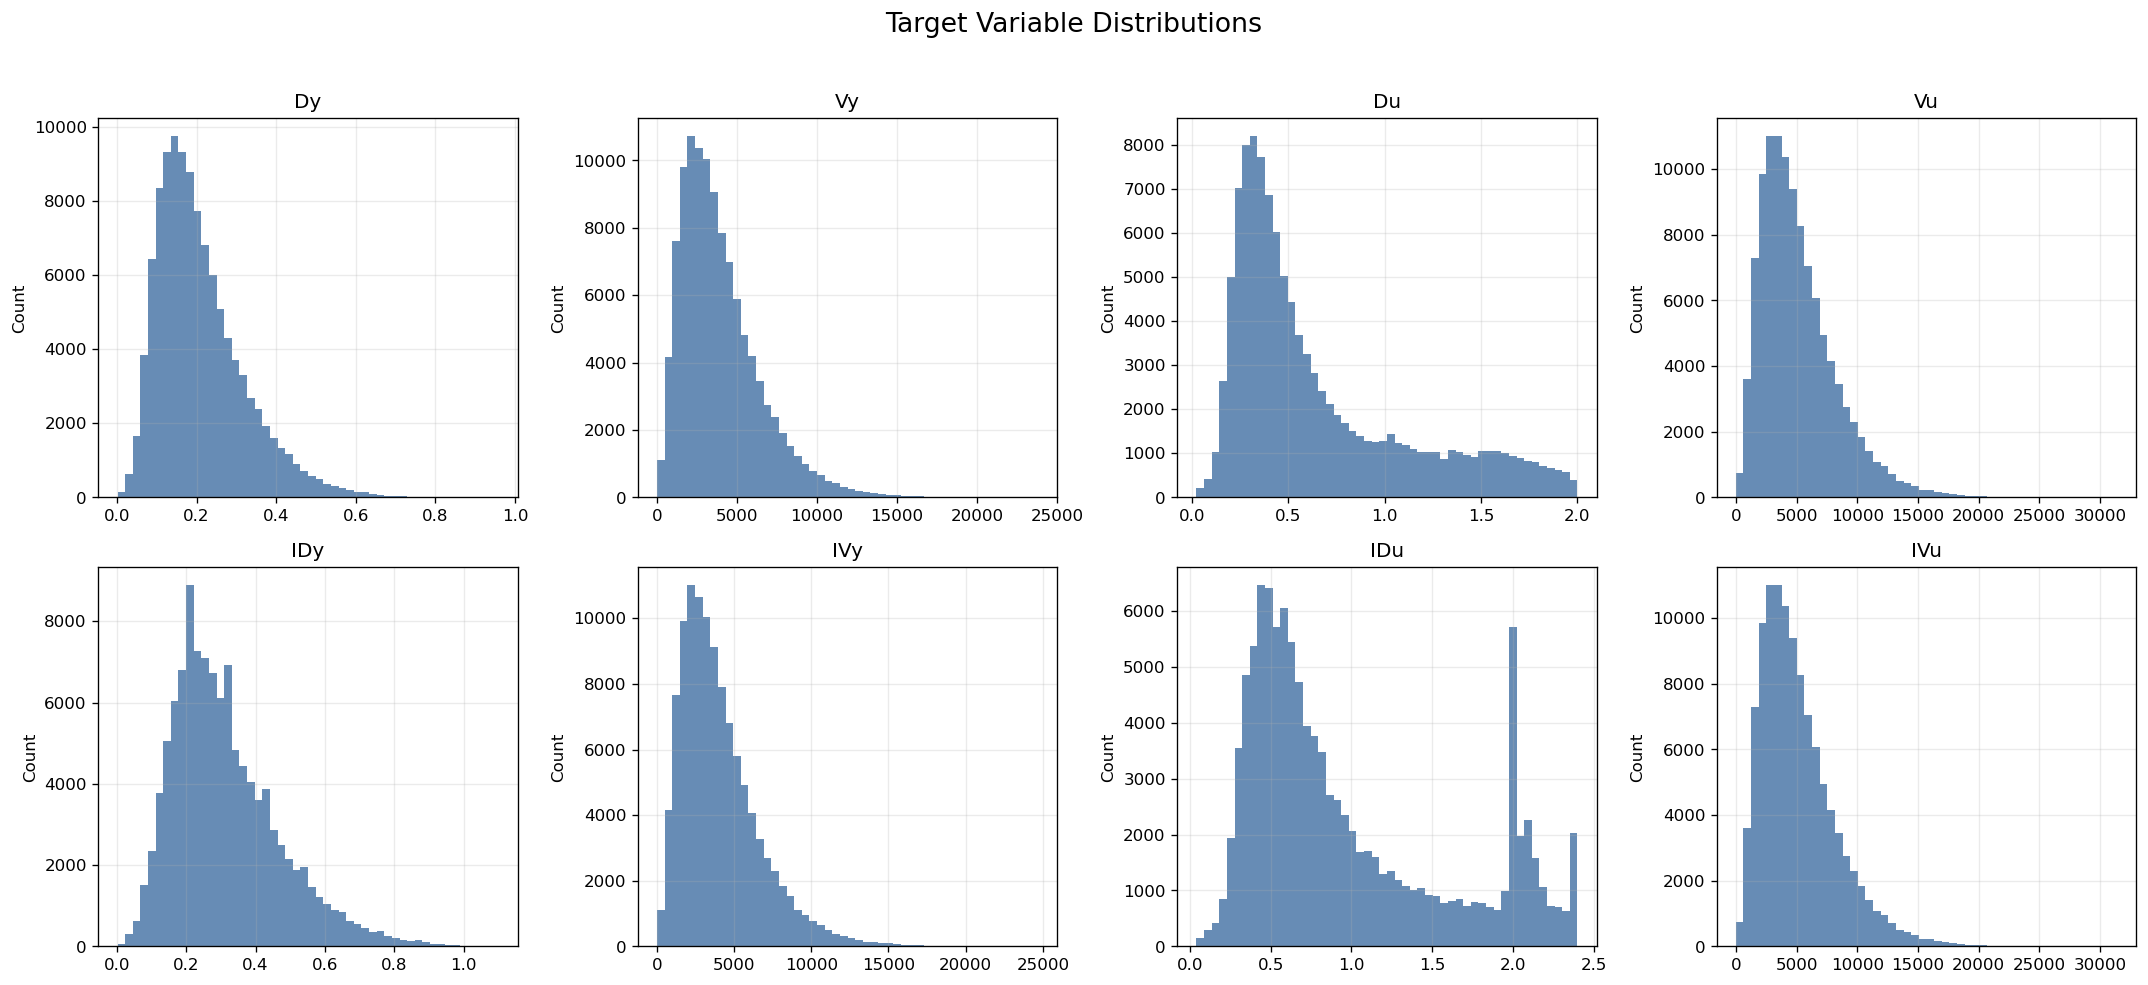

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), OUTPUT_COLS):
    ax.hist(df[col], bins=50, color="#4C78A8", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
fig.suptitle("Target Variable Distributions", y=1.02, fontsize=16)
plt.tight_layout()

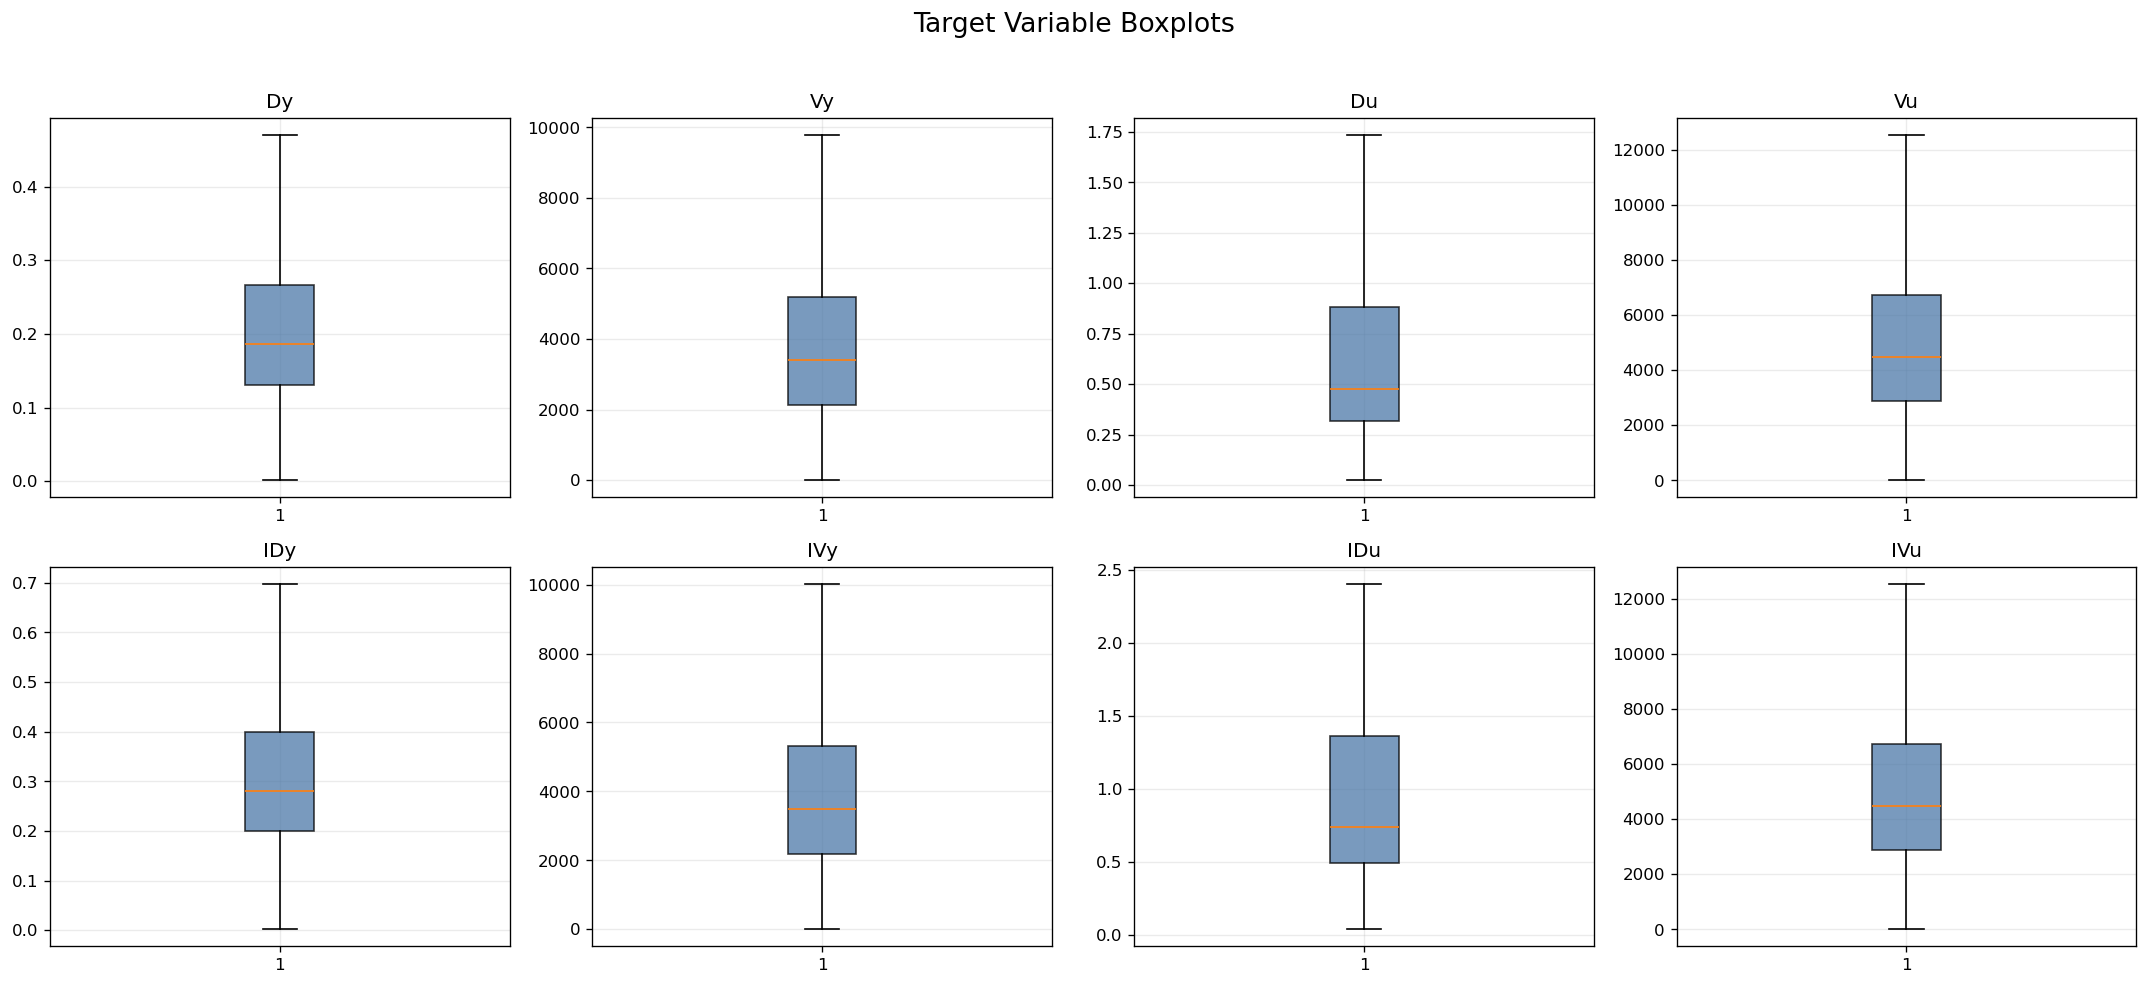

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), OUTPUT_COLS):
    box = ax.boxplot(df[col], patch_artist=True, showfliers=False)
    box["boxes"][0].set_facecolor("#4C78A8")
    box["boxes"][0].set_alpha(0.75)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Target Variable Boxplots", y=1.02, fontsize=16)
plt.tight_layout()

## 7. Input Feature Distributions

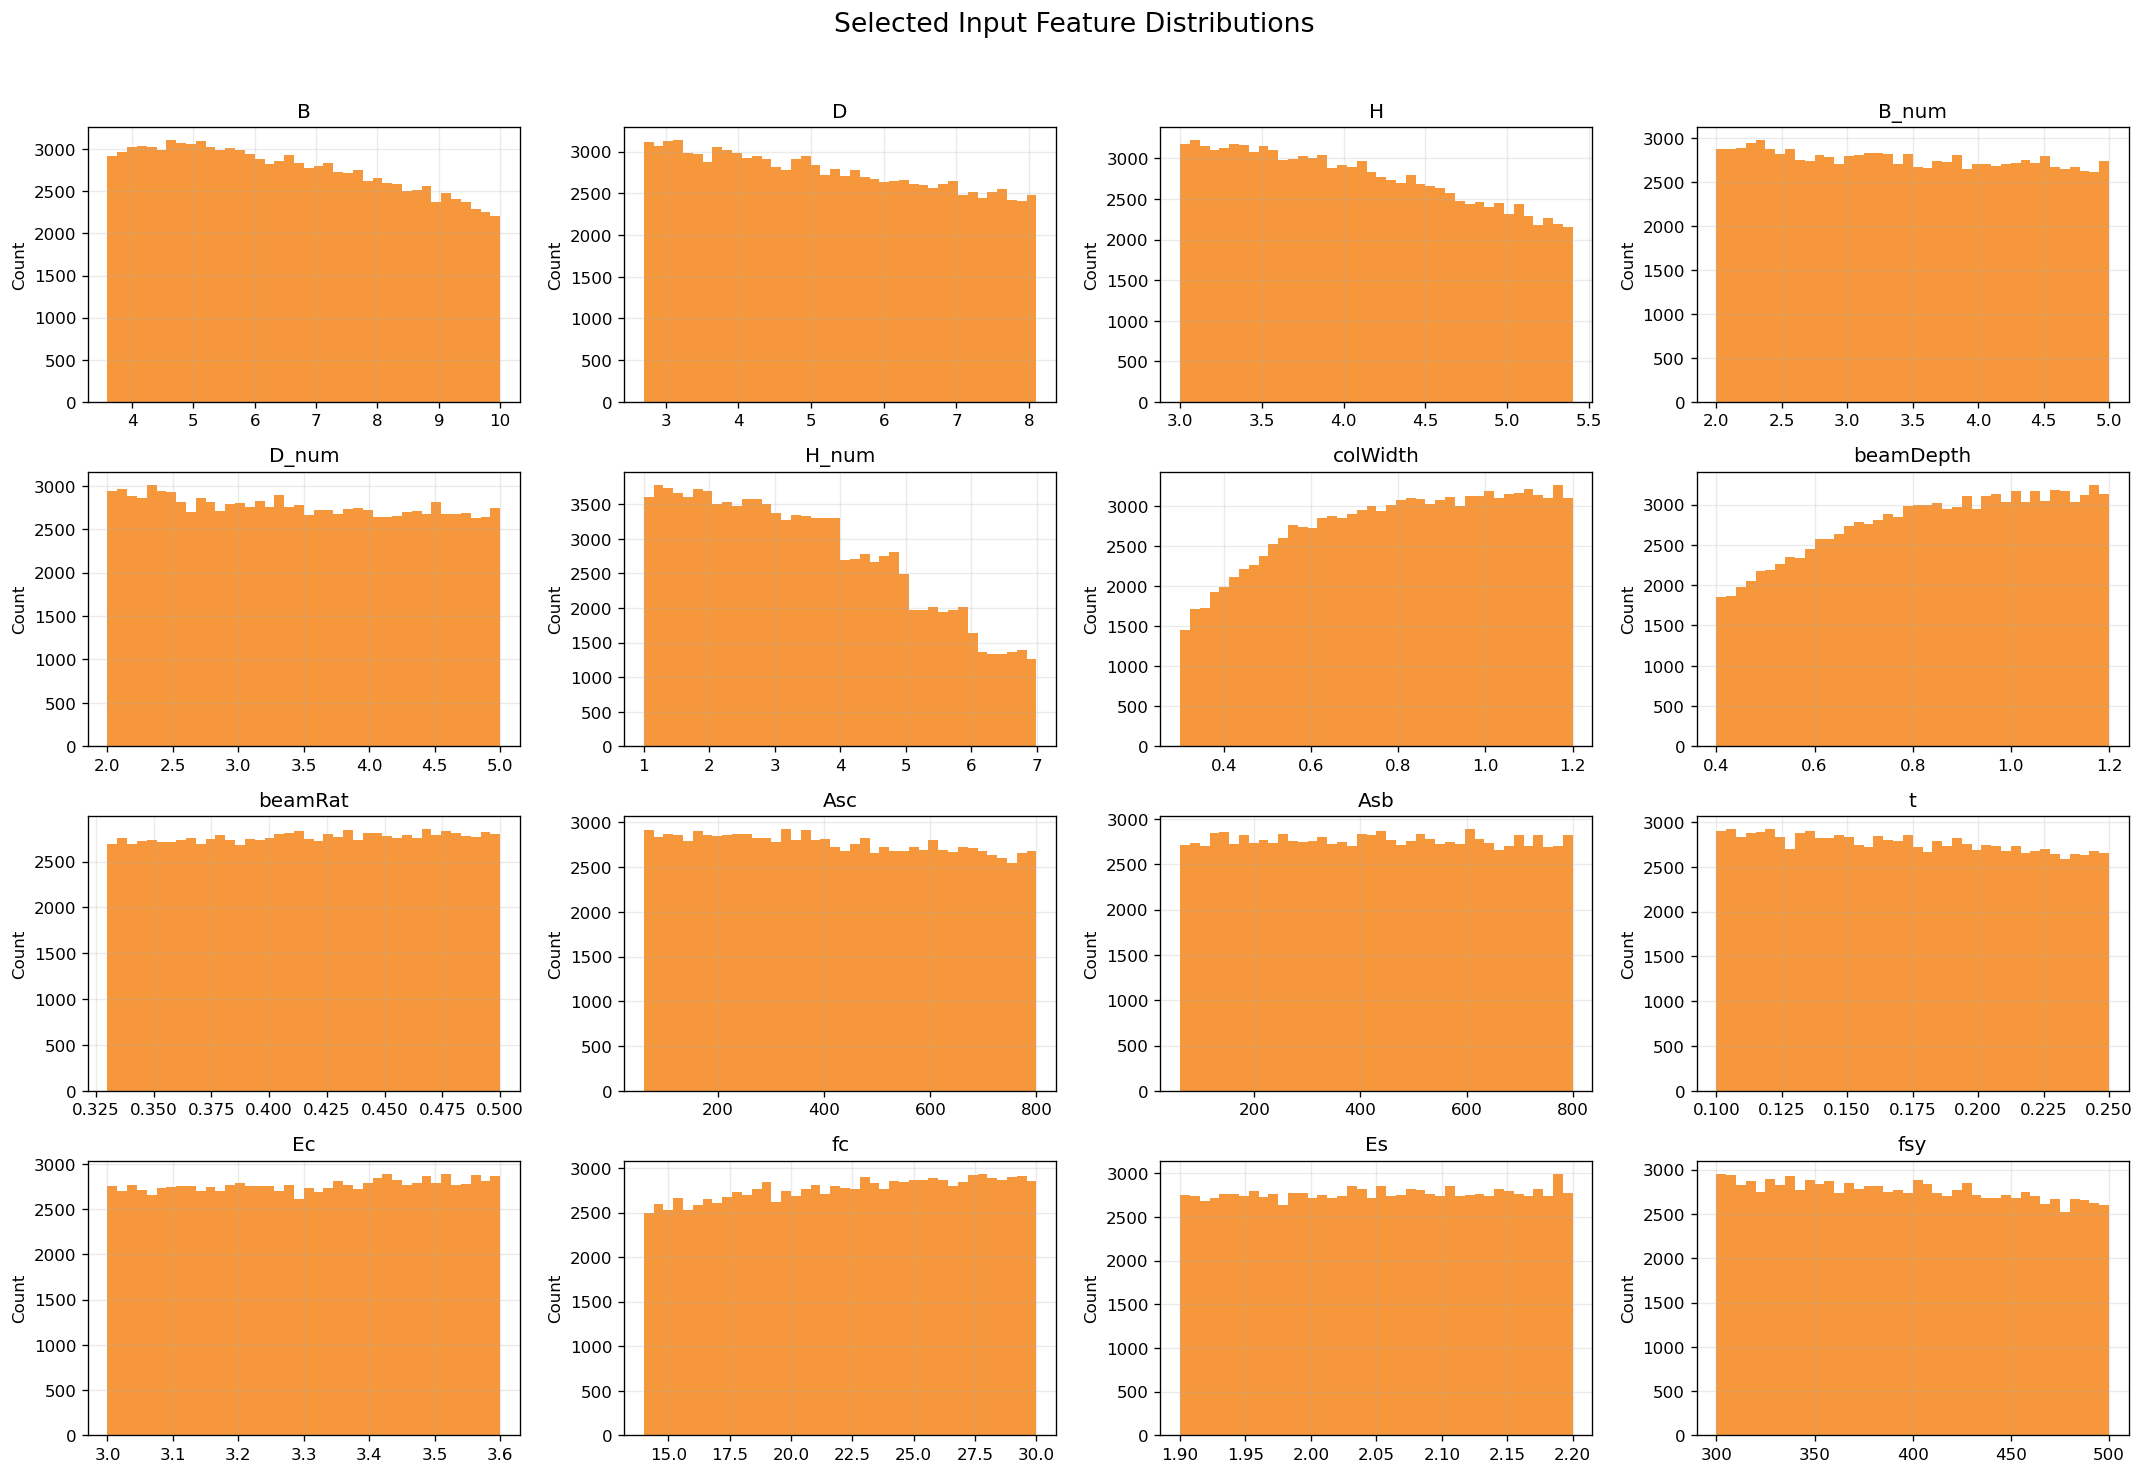

In [46]:
FEATURES_TO_PLOT = [
    "B", "D", "H", "B_num", "D_num", "H_num",
    "colWidth", "beamDepth", "beamRat", "Asc", "Asb", "t",
    "Ec", "fc", "Es", "fsy",
]

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
for ax, col in zip(axes.ravel(), FEATURES_TO_PLOT):
    ax.hist(df[col], bins=40, color="#F58518", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
fig.suptitle("Selected Input Feature Distributions", y=1.02, fontsize=16)
plt.tight_layout()

## 8. Target Relationships

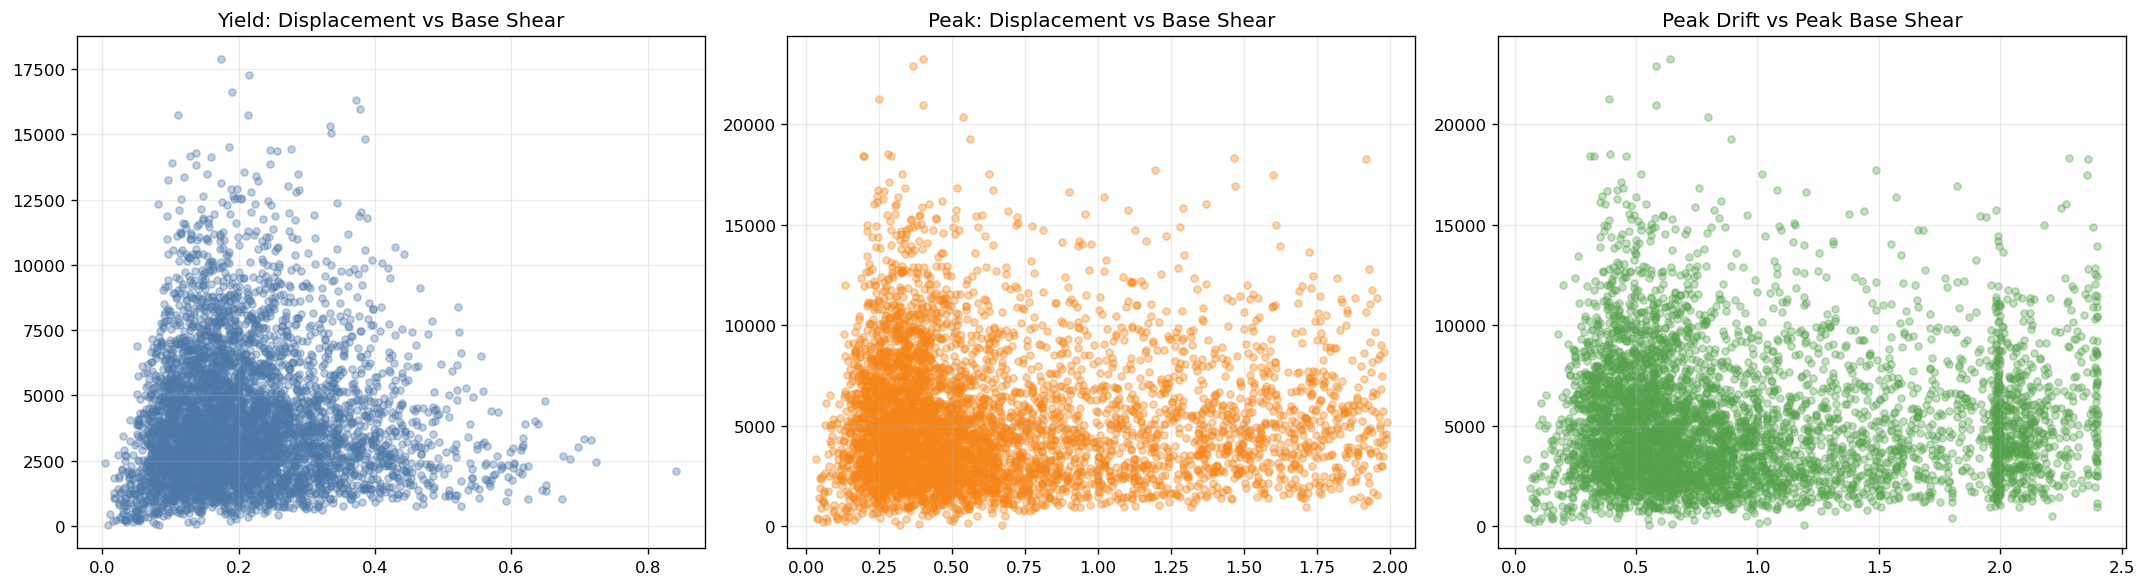

In [47]:
plot_sample = df.sample(n=min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(plot_sample["Dy"], plot_sample["Vy"], alpha=0.35, s=18, color="#4C78A8")
axes[0].set_title("Yield: Displacement vs Base Shear")

axes[1].scatter(plot_sample["Du"], plot_sample["Vu"], alpha=0.35, s=18, color="#F58518")
axes[1].set_title("Peak: Displacement vs Base Shear")

axes[2].scatter(plot_sample["IDu"], plot_sample["Vu"], alpha=0.35, s=18, color="#54A24B")
axes[2].set_title("Peak Drift vs Peak Base Shear")

plt.tight_layout()

## 9. Correlation Views

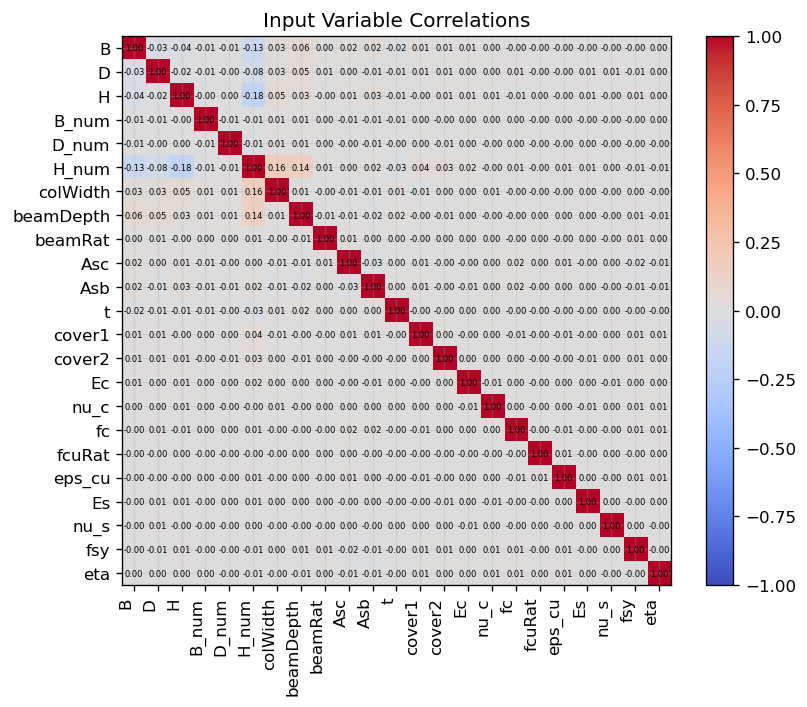

In [56]:
target_corr = df[INPUT_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(target_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(INPUT_COLS)), INPUT_COLS, rotation=90, ha="right")
ax.set_yticks(range(len(INPUT_COLS)), INPUT_COLS)
for row_idx, row in enumerate(target_corr.to_numpy()):
    for col_idx, value in enumerate(row):
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=5)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Input Variable Correlations")
plt.tight_layout()